## Imports

In [4]:
import torch
print("Torch:", torch.__version__, "| CUDA:", torch.version.cuda)

!pip install ninja
!pip install "git+https://github.com/facebookresearch/pytorch3d.git"

Torch: 2.11.0+cpu | CUDA: None



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/facebookresearch/pytorch3d.git to c:\users\mei qi\appdata\local\temp\pip-req-build-1d0uk22f
  Resolved https://github.com/facebookresearch/pytorch3d.git to commit fdaf9bd6fed7977e4c2056e7c77c640781e58fcd
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/pytorch3d.git 'C:\Users\Mei Qi\AppData\Local\Temp\pip-req-build-1d0uk22f'
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [23 lines of output]
      Traceback (most recent call last):
        File "C:\Python314\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "C:\Python314\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Python314\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
          return hook(config_settings)
        File "C:\Users\Mei Qi\AppData\Local\Temp\pip-b

In [5]:
import os
import sys
import torch
import subprocess
import pytorch3d
from pathlib import Path

ModuleNotFoundError: No module named 'pytorch3d'

In [ ]:
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.ops import sample_points_from_meshes
from pytorch3d.loss import (
    chamfer_distance, 
    mesh_edge_loss, 
    mesh_laplacian_smoothing, 
    mesh_normal_consistency,
)

In [ ]:
import numpy as np
from tqdm.notebook import tqdm
%matplotlib notebook 
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['savefig.dpi'] = 80
mpl.rcParams['figure.dpi'] = 80

In [ ]:
import plotly.graph_objects as go

In [ ]:
import trimesh

In [ ]:
import numpy as np

In [ ]:
import time

In [ ]:
from pycpd import DeformableRegistration

In [ ]:
from scipy.spatial.distance import directed_hausdorff
from scipy.spatial import cKDTree

## Functions

In [ ]:
def rotation_matrix_from_vectors(a, b):
    """
    Rotate vector a to vector b
    """
    a = a / np.linalg.norm(a)
    b = b / np.linalg.norm(b)

    cross = np.cross(a,b)
    dot = np.dot(a,b)

    if np.isclose(dot,1):
        return np.eye(3)

    if np.isclose(dot,-1):
        # opposite direction
        axis = np.array([1,0,0])
        if np.allclose(a,axis):
            axis=np.array([0,1,0])
        v = axis - axis.dot(a)*a
        v /= np.linalg.norm(v)

        return (
            -np.eye(3)
            + 2*np.outer(v,v)
        )

    skew = np.array([
        [0,-cross[2],cross[1]],
        [cross[2],0,-cross[0]],
        [-cross[1],cross[0],0]
    ])

    R = (
        np.eye(3)
        + skew
        + skew @ skew * ((1-dot)/(np.linalg.norm(cross)**2))
    )

    return R

In [ ]:
def apply_cpd_field(reg, vertices):

    """
    Apply CPD deformation to arbitrary vertices.

    vertices:
        (V,3)

    returns:
        deformed vertices (V,3)
    """
    Y = reg.Y
    W = reg.W
    beta = reg.beta

    # Gaussian kernel
    diff = vertices[:, None, :]-Y[None, :, :]
    G = np.exp(-np.sum(diff**2, axis=2)/(2 * beta**2))

    # deformation vector
    displacement = G @ W
    vertices_deformed = vertices + displacement

    return vertices_deformed

## Load Heart (Personalised)
for a given obj, find the highest point then, translate the obj so its centroid is at (0,0,0) then, using its centroid as the center of rotation, rotate the highest point so that it is parallel to the negative z axis then normalize the obj to [1,-1] plot

In [ ]:

# ===========================
# Load OBJ
# ===========================
trg_obj = "C:/Users/User/Documents/HDR/assets/frame00.obj"

verts, faces, aux = load_obj(trg_obj)

verts = verts.cpu().numpy()
faces_idx = faces.verts_idx.cpu().numpy()


# ===========================
# 1. Find centroid
# ===========================
centroid = verts.mean(axis=0)

print("Original centroid:", centroid)


# ===========================
# 2. Translate centroid to origin
# ===========================
verts_centered = verts - centroid


# ===========================
# 3. Find highest point
#    (largest Z)
# ===========================
highest_idx = np.argmax(verts_centered[:,2])
highest_point = verts_centered[highest_idx]

print("Highest point after centering:", highest_point)


# vector from center -> apex
v = highest_point / np.linalg.norm(highest_point)


# target direction = negative Z axis
target = np.array([0,0,-1])


# ===========================
# 4. Rotation matrix
#    align v -> target
# ===========================

R = rotation_matrix_from_vectors(v,target)


# apply rotation
verts_rotated = verts_centered @ R.T


# ===========================
# 5. Normalize to [-1,1]
# ===========================

scale = np.max(np.abs(verts_rotated))

verts_norm = verts_rotated / scale


print("Normalized range:")
print(verts_norm.min(axis=0))
print(verts_norm.max(axis=0))

Original centroid: [88.89228   87.33467    7.9452386]
Highest point after centering: [ 0.31388092 -4.0844727  22.305695  ]
Normalized range:
[-0.67980717 -0.58674516 -1.        ]
[0.64987674 0.65269504 0.88835098]


C:\Users\User\anaconda3\envs\hdr2026\Lib\site-packages\pytorch3d\io\obj_io.py:547: UserWarning: No mtl file provided
  warnings.warn("No mtl file provided")


In [ ]:
# Convert vertices back to a tensor
verts_norm_tensor = torch.tensor(
    verts_norm,
    dtype=torch.float32
)

# Convert faces back to a tensor
faces_tensor = torch.tensor(
    faces_idx,
    dtype=torch.int64
)

# Create a Meshes object
mesh_norm = Meshes(
    verts=[verts_norm_tensor],
    faces=[faces_tensor]
)

print(mesh_norm)

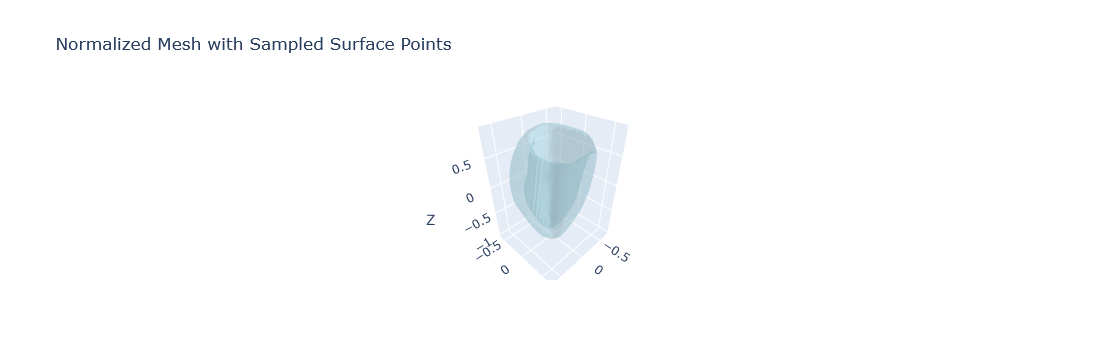

In [ ]:
# Mesh vertices and faces
verts = mesh_norm.verts_packed().cpu().numpy()
faces = mesh_norm.faces_packed().cpu().numpy()

fig = go.Figure()

# Mesh surface
fig.add_trace(go.Mesh3d(
    x=verts[:, 0],
    y=verts[:, 1],
    z=verts[:, 2],
    i=faces[:, 0],
    j=faces[:, 1],
    k=faces[:, 2],
    color="lightblue",
    opacity=0.35,
    name="Mesh"
))

# # Origin
# fig.add_trace(go.Scatter3d(
#     x=[0],
#     y=[0],
#     z=[0],
#     mode="markers",
#     # marker=dict(size=6, color="red", symbol="cross"),
#     name="Origin"
# ))

fig.update_layout(
    title="Normalized Mesh with Sampled Surface Points",
    scene=dict(
        aspectmode="data",
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z"
    ),
    showlegend=True
)

fig.show()

## Load Heart (17-Segment, Generic)

In [ ]:
# ==========================================================
# 1. Load OBJ meshes
# ==========================================================

obj_folder = [
    Path("C:/Users/User/Documents/HDR/assets/SeptalLV"),
    Path("C:/Users/User/Documents/HDR/assets/InferiorPosteriorLV"),
    Path("C:/Users/User/Documents/HDR/assets/LateralLV"),
    Path("C:/Users/User/Documents/HDR/assets/AnteriorLV")
]


mesh_dict = {}

for each_path in obj_folder:
    for obj_file in sorted(each_path.glob("*.obj")):

        obj_filename = str(obj_file).replace(str(each_path), "")
        print(obj_filename)

        verts, faces, aux = load_obj(obj_file)

        mesh = Meshes(
            verts=[verts],
            faces=[faces.verts_idx]
        )

        mesh_dict[obj_filename] = mesh


print(f"Loaded {len(mesh_dict)} meshes.")



# ==========================================================
# 2. Calculate global mean center
#    (mean of individual mesh centroids)
# ==========================================================

centroids = []

for name, mesh in mesh_dict.items():

    centroid = mesh.verts_packed().mean(dim=0)
    centroids.append(centroid)


global_mean_center = torch.stack(centroids).mean(dim=0)

print("Global mean center:")
print(global_mean_center)



# ==========================================================
# 3. Translate all meshes to origin
# ==========================================================

translated_meshes = {}

translation = -global_mean_center


for name, mesh in mesh_dict.items():

    verts = mesh.verts_packed()

    verts_new = verts + translation

    translated_meshes[name] = Meshes(
        verts=[verts_new],
        faces=[mesh.faces_packed()]
    )


# verify
new_centroids = [
    mesh.verts_packed().mean(dim=0)
    for mesh in translated_meshes.values()
]

print("After translation:")
print(torch.stack(new_centroids).mean(dim=0))



# ==========================================================
# 4. Rotate selected centroid to negative Z-axis
# ==========================================================

selected_name = "\MM628_BP52011_FMA9560_Anterior.obj"  


selected_centroid = (
    translated_meshes[selected_name]
    .verts_packed()
    .mean(dim=0)
)


# normalize vector
v = selected_centroid / torch.norm(selected_centroid)

target = torch.tensor(
    [0.,0.,-1.],
    device=v.device
)


# ==========================================================
# 4. Rotate selected centroid to negative Z-axis
# ==========================================================

selected_name = "\\MM628_BP52011_FMA9560_Anterior.obj"


# get selected centroid
selected_centroid = (
    translated_meshes[selected_name]
    .verts_packed()
    .mean(dim=0)
)


# convert torch -> numpy
v = selected_centroid.cpu().numpy()

target = np.array([0,0,-1])


# calculate rotation
R = rotation_matrix_from_vectors(v, target)


# convert back to torch
R = torch.tensor(
    R,
    dtype=torch.float32,
    device=selected_centroid.device
)


# apply rotation
rotated_meshes = {}

for name, mesh in translated_meshes.items():

    verts = mesh.verts_packed()

    verts_rot = verts @ R.T

    rotated_meshes[name] = Meshes(
        verts=[verts_rot],
        faces=[mesh.faces_packed()]
    )


# verify selected centroid
print("Rotated selected centroid:")
print(
    rotated_meshes[selected_name]
    .verts_packed()
    .mean(dim=0)
)


# ==========================================================
# 5. Normalize whole set to [-1,1]
# ==========================================================

all_vertices = torch.cat(
    [m.verts_packed() for m in rotated_meshes.values()],
    dim=0
)

scale = torch.max(torch.abs(all_vertices))


normalized_meshes = {}

for name, mesh in rotated_meshes.items():

    verts = mesh.verts_packed()/scale

    normalized_meshes[name] = Meshes(
        verts=[verts],
        faces=[mesh.faces_packed()]
    )


print("Normalization scale:", scale)


\MM613_BP52013_FMA9345_Septal.obj
\MM618_BP52013_FMA9345_Septal.obj
\MM619_BP52013_FMA9345_Septal.obj
\MM625_BP52013_FMA9345_Septal.obj
\MM629_BP52013_FMA9345_Septal.obj


C:\Users\User\anaconda3\envs\hdr2026\Lib\site-packages\pytorch3d\io\obj_io.py:547: UserWarning: No mtl file provided
  warnings.warn("No mtl file provided")


\MM616_BP52012_FMA9561_Inferior.obj
\MM622_BP52012_FMA9561_Inferior.obj
\MM623_BP52012_FMA9561_Inferior.obj
\MM626_BP52012_FMA9561_Inferior.obj
\MM631_BP52012_FMA9561_Inferior.obj
\MM615_BP52010_FMA9563_Lateral.obj
\MM621_BP52010_FMA9563_Lateral.obj
\MM627_BP52010_FMA9563_Lateral.obj
\MM614_BP52011_FMA9560_Anterior.obj
\MM620_BP52011_FMA9560_Anterior.obj
\MM624_BP52011_FMA9560_Anterior.obj
\MM628_BP52011_FMA9560_Anterior.obj
Loaded 17 meshes.
Global mean center:
tensor([  43.9789, -127.4481, 1208.5258])
After translation:
tensor([2.0195e-06, 2.2439e-07, 4.7011e-05])
Rotated selected centroid:
tensor([-8.7282e-07, -6.3903e-07, -3.7293e+01])
Normalization scale: tensor(44.1410)


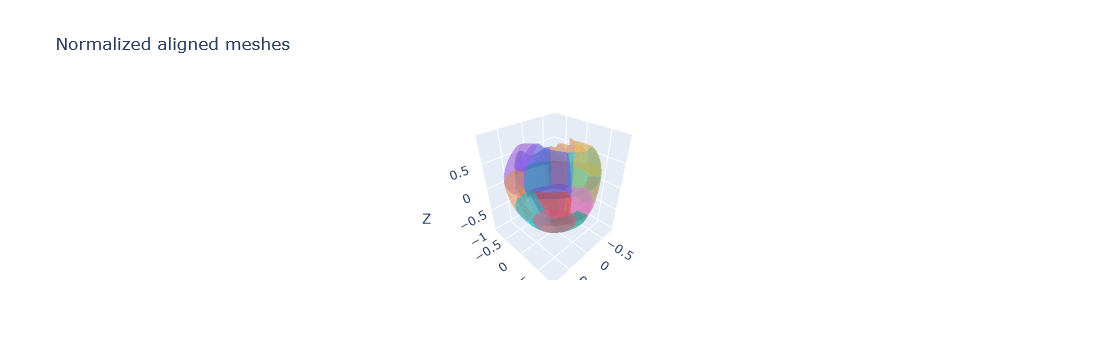

In [ ]:
# ==========================================================
# 6. Plot
# ==========================================================

fig = go.Figure()


for name, mesh in normalized_meshes.items():

    verts = mesh.verts_packed().cpu().numpy()
    faces = mesh.faces_packed().cpu().numpy()


    fig.add_trace(go.Mesh3d(
        x=verts[:,0],
        y=verts[:,1],
        z=verts[:,2],
        i=faces[:,0],
        j=faces[:,1],
        k=faces[:,2],
        opacity=0.35,
        name=name
    ))


fig.update_layout(
    title="Normalized aligned meshes",
    scene=dict(
        aspectmode="data",
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z"
    ),
)


fig.show()

## Deform

In [ ]:
mesh_norm

In [ ]:
normalized_meshes

{'\\MM613_BP52013_FMA9345_Septal.obj': <pytorch3d.structures.meshes.Meshes at 0x204975e0c90>,
 '\\MM618_BP52013_FMA9345_Septal.obj': <pytorch3d.structures.meshes.Meshes at 0x20498130ed0>,
 '\\MM619_BP52013_FMA9345_Septal.obj': <pytorch3d.structures.meshes.Meshes at 0x2048d259150>,
 '\\MM625_BP52013_FMA9345_Septal.obj': <pytorch3d.structures.meshes.Meshes at 0x20498131a10>,
 '\\MM629_BP52013_FMA9345_Septal.obj': <pytorch3d.structures.meshes.Meshes at 0x20498132310>,
 '\\MM616_BP52012_FMA9561_Inferior.obj': <pytorch3d.structures.meshes.Meshes at 0x2048c4aa9d0>,
 '\\MM622_BP52012_FMA9561_Inferior.obj': <pytorch3d.structures.meshes.Meshes at 0x204981332d0>,
 '\\MM623_BP52012_FMA9561_Inferior.obj': <pytorch3d.structures.meshes.Meshes at 0x2049767be10>,
 '\\MM626_BP52012_FMA9561_Inferior.obj': <pytorch3d.structures.meshes.Meshes at 0x204975b0950>,
 '\\MM631_BP52012_FMA9561_Inferior.obj': <pytorch3d.structures.meshes.Meshes at 0x204981316d0>,
 '\\MM615_BP52010_FMA9563_Lateral.obj': <pytorch3d

### Sampling

In [ ]:
A_prime = (sample_points_from_meshes(mesh_norm, 3000))[0].detach().cpu().numpy()

In [ ]:
type(A_prime)

numpy.ndarray

In [ ]:
B_prime = {}

for name, mesh in normalized_meshes.items():
    
    # sample surface points
    points = sample_points_from_meshes(mesh, num_samples=500)

    # remove batch dimension
    points = points[0].detach().cpu().numpy()

    B_prime[name] = points

### Aggregate (Points)

In [ ]:
# concatenate all sampled B points
B_aggregate = np.vstack(
    list(B_prime.values())
)

print("A:", A_prime.shape)
print("B aggregate:", B_aggregate.shape)

A: (3000, 3)
B aggregate: (8500, 3)


In [ ]:
start_time = time.perf_counter()

reg = DeformableRegistration(
    X=A_prime,          # target
    Y=B_aggregate,      # source

    beta=1.5,
    lamb=10.0,
    max_iterations=30
)

TY, params = reg.register()

end_time = time.perf_counter()

elapsed_time = end_time - start_time
print(f"Code executed in: {elapsed_time:.4f} seconds")

Code executed in: 258.3121 seconds


In [ ]:
print(TY.shape)

(8500, 3)


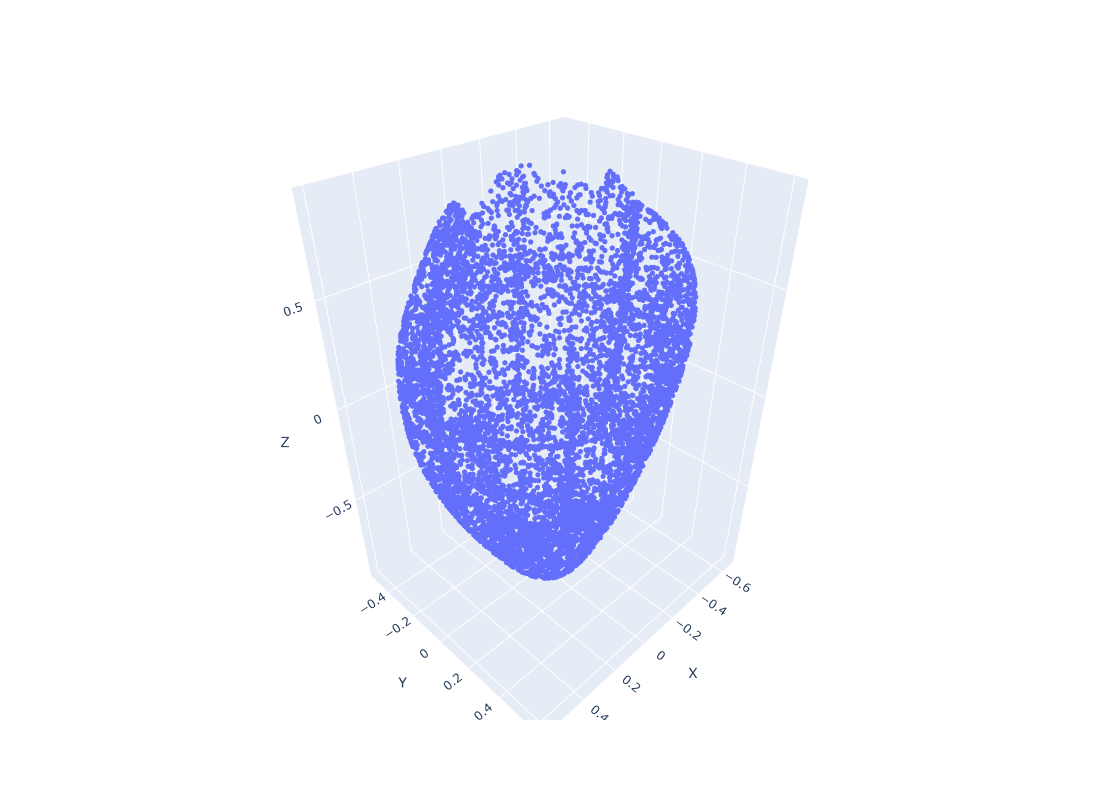

In [ ]:
fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=TY[:, 0],
        y=TY[:, 1],
        z=TY[:, 2],
        mode="markers",
        marker=dict(
            size=3
        ),
        name="B' after CPD"
    )
)

fig.update_layout(
    width=800,
    height=800,
    scene=dict(
        aspectmode="data",
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z"
    )
)

fig.show()

## Deform meshes instead of points

In [ ]:
B_deformed = {}


for name, mesh in normalized_meshes.items():

    print("Deforming:", name)

    # -------------------------
    # Original vertices
    # -------------------------
    verts = (mesh.verts_packed().detach().cpu().numpy())

    # -------------------------
    # Apply CPD field
    # -------------------------
    verts_def = apply_cpd_field(reg,verts)

    # -------------------------
    # Keep faces
    # -------------------------
    faces = mesh.faces_packed().detach().cpu()

    # -------------------------
    # Create new mesh
    # -------------------------
    B_deformed[name] = Meshes(
        verts=[torch.tensor(verts_def,dtype=torch.float32)],
        faces=[faces]
    )

Deforming: \MM613_BP52013_FMA9345_Septal.obj
Deforming: \MM618_BP52013_FMA9345_Septal.obj
Deforming: \MM619_BP52013_FMA9345_Septal.obj
Deforming: \MM625_BP52013_FMA9345_Septal.obj
Deforming: \MM629_BP52013_FMA9345_Septal.obj
Deforming: \MM616_BP52012_FMA9561_Inferior.obj
Deforming: \MM622_BP52012_FMA9561_Inferior.obj
Deforming: \MM623_BP52012_FMA9561_Inferior.obj
Deforming: \MM626_BP52012_FMA9561_Inferior.obj
Deforming: \MM631_BP52012_FMA9561_Inferior.obj
Deforming: \MM615_BP52010_FMA9563_Lateral.obj
Deforming: \MM621_BP52010_FMA9563_Lateral.obj
Deforming: \MM627_BP52010_FMA9563_Lateral.obj
Deforming: \MM614_BP52011_FMA9560_Anterior.obj
Deforming: \MM620_BP52011_FMA9560_Anterior.obj
Deforming: \MM624_BP52011_FMA9560_Anterior.obj
Deforming: \MM628_BP52011_FMA9560_Anterior.obj


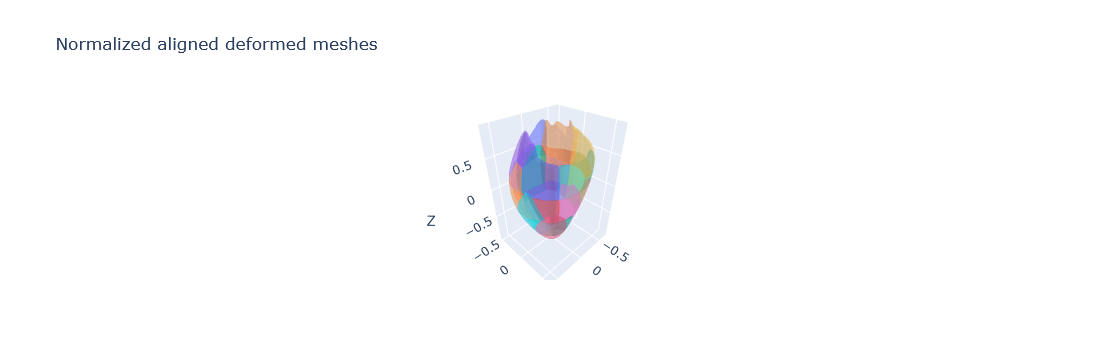

In [ ]:
# ==========================================================
# 6. Plot
# ==========================================================

fig = go.Figure()


for name, mesh in B_deformed.items():

    verts = mesh.verts_packed().cpu().numpy()
    faces = mesh.faces_packed().cpu().numpy()


    fig.add_trace(go.Mesh3d(
        x=verts[:,0],
        y=verts[:,1],
        z=verts[:,2],
        i=faces[:,0],
        j=faces[:,1],
        k=faces[:,2],
        opacity=0.35,
        name=name
    ))


fig.update_layout(
    title="Normalized aligned deformed meshes",
    scene=dict(
        aspectmode="data",
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z"
    ),
)


fig.show()

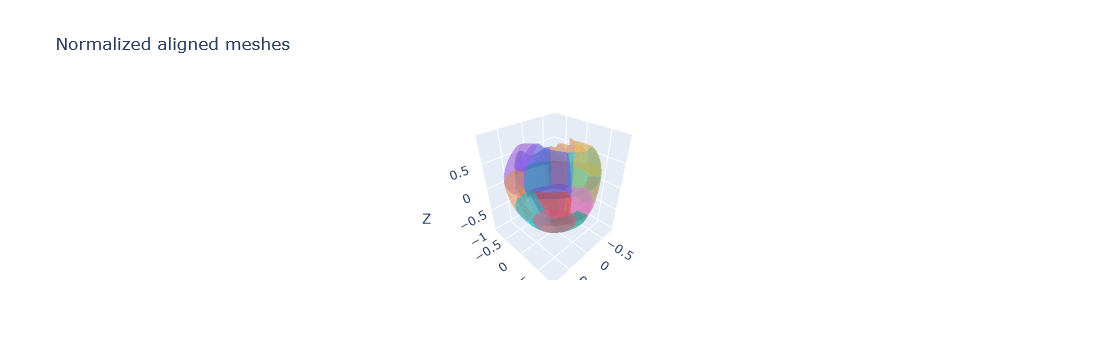

In [ ]:
# ==========================================================
# 6. Plot
# ==========================================================

fig = go.Figure()


for name, mesh in normalized_meshes.items():

    verts = mesh.verts_packed().cpu().numpy()
    faces = mesh.faces_packed().cpu().numpy()


    fig.add_trace(go.Mesh3d(
        x=verts[:,0],
        y=verts[:,1],
        z=verts[:,2],
        i=faces[:,0],
        j=faces[:,1],
        k=faces[:,2],
        opacity=0.35,
        name=name
    ))


fig.update_layout(
    title="Normalized aligned meshes",
    scene=dict(
        aspectmode="data",
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z"
    ),
)


fig.show()

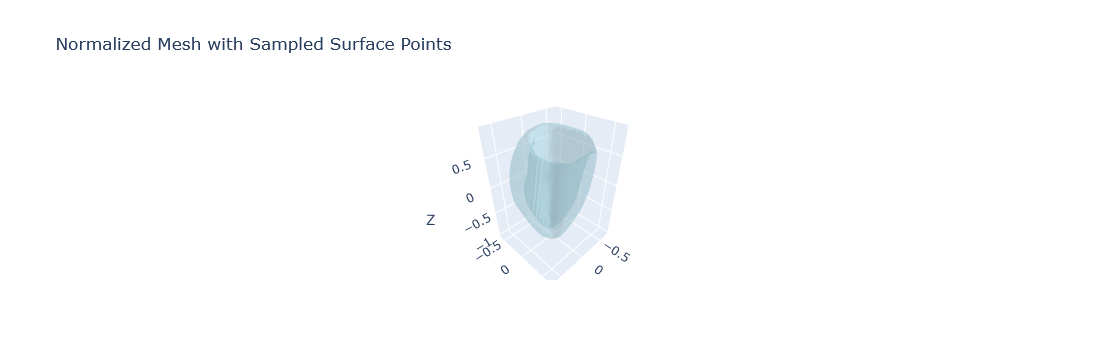

In [ ]:
# Mesh vertices and faces
verts = mesh_norm.verts_packed().cpu().numpy()
faces = mesh_norm.faces_packed().cpu().numpy()

fig = go.Figure()

# Mesh surface
fig.add_trace(go.Mesh3d(
    x=verts[:, 0],
    y=verts[:, 1],
    z=verts[:, 2],
    i=faces[:, 0],
    j=faces[:, 1],
    k=faces[:, 2],
    color="lightblue",
    opacity=0.35,
    name="Mesh"
))

# # Origin
# fig.add_trace(go.Scatter3d(
#     x=[0],
#     y=[0],
#     z=[0],
#     mode="markers",
#     # marker=dict(size=6, color="red", symbol="cross"),
#     name="Origin"
# ))

fig.update_layout(
    title="Normalized Mesh with Sampled Surface Points",
    scene=dict(
        aspectmode="data",
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z"
    ),
    showlegend=True
)

fig.show()

## Check Chamfer Distance (point distance)
## (Between personalized and deformed generalized)

In [ ]:
A_prime = (sample_points_from_meshes(mesh_norm, 8500))[0].detach().cpu().numpy()

In [ ]:
B_prime_deformed = {}

for name, mesh in B_deformed.items():
    # sample surface points
    points = sample_points_from_meshes(mesh, num_samples=500)
    # remove batch dimension
    points = points[0].detach().cpu().numpy()
    B_prime_deformed[name] = points

In [ ]:
# concatenate all sampled B points
B_aggregate_deformed = np.vstack(
    list(B_prime_deformed.values())
)

print("A:", A_prime.shape)
print("B aggregate:", B_aggregate_deformed.shape)

A: (8500, 3)
B aggregate: (8500, 3)


In [ ]:
# convert numpy -> torch tensor
A_tensor = torch.tensor(A_prime, dtype=torch.float32).unsqueeze(0)
B_tensor = torch.tensor(B_aggregate_deformed,dtype=torch.float32).unsqueeze(0)

In [ ]:
loss, _ = chamfer_distance(A_tensor, B_tensor)

In [ ]:
print("Chamfer distance:", loss.item())

Chamfer distance: 0.005458016414195299


## Check Chamfer Distance (Between personalized and original generalized)

In [ ]:
A_prime = (sample_points_from_meshes(mesh_norm, 8500))[0].detach().cpu().numpy()

In [ ]:
B_original = {}

for name, mesh in normalized_meshes.items():
    # sample surface points
    points = sample_points_from_meshes(mesh, num_samples=500)
    # remove batch dimension
    points = points[0].detach().cpu().numpy()
    B_original[name] = points

# concatenate all sampled B points
B_original = np.vstack(
    list(B_original.values())
)

print("A:", A_prime.shape)
print("B aggregate:", B_original.shape)

A: (8500, 3)
B aggregate: (8500, 3)


In [ ]:
# convert numpy -> torch tensor
A_tensor = torch.tensor(A_prime, dtype=torch.float32).unsqueeze(0)
B_tensor_original = torch.tensor(B_original,dtype=torch.float32).unsqueeze(0)

In [ ]:
closs, _ = chamfer_distance(A_tensor, B_tensor_original)
print("Chamfer distance:", closs.item())

Chamfer distance: 0.021819859743118286


## Check Chamfer Distance (Between original generalized and deformed generalized)

In [ ]:
closs, _ = chamfer_distance(B_tensor, B_tensor_original)
print("Chamfer distance:", closs.item())

Chamfer distance: 0.02693832293152809


## Check Hausdorff Distance

In [ ]:
def hausdorff_distance(points_A, points_B):

    """
    points_A: (N,3) numpy array
    points_B: (M,3) numpy array
    """
    d_AB = directed_hausdorff(points_A,points_B)[0]
    d_BA = directed_hausdorff(points_B,points_A)[0]
    HD = max(d_AB,d_BA)

    return HD

In [ ]:
def hausdorff_distance95(points_A, points_B):

    tree_A = cKDTree(points_A)
    tree_B = cKDTree(points_B)

    d_AB = tree_B.query(points_A)[0]
    d_BA = tree_A.query(points_B)[0]

    all_distances = np.concatenate([d_AB,d_BA])

    return np.percentile(all_distances, 95)

In [ ]:
hd_1 = hausdorff_distance(A_prime, B_aggregate_deformed)
print("Between personalized and deformed generalized", hd_1) 

Between personalized and deformed generalized 0.1935117867955003


In [ ]:
hd95_1 = hausdorff_distance95(A_prime, B_aggregate_deformed)
print("HD95 Between personalized and deformed generalized", hd95_1) 

HD95 Between personalized and deformed generalized 0.08503267042106769


In [ ]:
hd_2 = hausdorff_distance(A_prime, B_original)
print("Between personalized and original generalized", hd_2) 

Between personalized and original generalized 0.38362405951822126


In [ ]:
hd95_2 = hausdorff_distance95(A_prime, B_original)
print("HD95 Between personalized and original generalized", hd95_2) 

HD95 Between personalized and original generalized 0.21121139033574607


In [ ]:
hd_3 = hausdorff_distance(B_original, B_aggregate_deformed)
print("Between original generalized and deformed generalized", hd_3) 

Between original generalized and deformed generalized 0.3376219236267605


In [ ]:
hd95_3 = hausdorff_distance95(B_original, B_aggregate_deformed)
print("HD95 Between original generalized and deformed generalized", hd95_3) 

HD95 Between original generalized and deformed generalized 0.24054663095721585


## Save Deformed meshes

In [ ]:
B_deformed

{'\\MM613_BP52013_FMA9345_Septal.obj': <pytorch3d.structures.meshes.Meshes at 0x20497671990>,
 '\\MM618_BP52013_FMA9345_Septal.obj': <pytorch3d.structures.meshes.Meshes at 0x204973ff910>,
 '\\MM619_BP52013_FMA9345_Septal.obj': <pytorch3d.structures.meshes.Meshes at 0x2049737fe10>,
 '\\MM625_BP52013_FMA9345_Septal.obj': <pytorch3d.structures.meshes.Meshes at 0x20497fffa10>,
 '\\MM629_BP52013_FMA9345_Septal.obj': <pytorch3d.structures.meshes.Meshes at 0x20497ffd210>,
 '\\MM616_BP52012_FMA9561_Inferior.obj': <pytorch3d.structures.meshes.Meshes at 0x204981408d0>,
 '\\MM622_BP52012_FMA9561_Inferior.obj': <pytorch3d.structures.meshes.Meshes at 0x2048eb635d0>,
 '\\MM623_BP52012_FMA9561_Inferior.obj': <pytorch3d.structures.meshes.Meshes at 0x20497673110>,
 '\\MM626_BP52012_FMA9561_Inferior.obj': <pytorch3d.structures.meshes.Meshes at 0x20498141950>,
 '\\MM631_BP52012_FMA9561_Inferior.obj': <pytorch3d.structures.meshes.Meshes at 0x20498143450>,
 '\\MM615_BP52010_FMA9563_Lateral.obj': <pytorch3d

In [ ]:
output_folder = Path("C:/Users/User/Documents/HDR/assets/deformed_meshes")

output_folder.mkdir(parents=True, exist_ok=True)

for name, mesh in B_deformed.items():

    print("Saving:", name)

    # get vertices
    verts = mesh.verts_packed().detach().cpu()
    # get faces
    faces = mesh.faces_packed().detach().cpu()
    # output path
    save_path = output_folder / name.split("\\")[-1]

    save_obj(str(save_path),verts,faces)

print("All meshes saved.")

Saving: \MM613_BP52013_FMA9345_Septal.obj
Saving: \MM618_BP52013_FMA9345_Septal.obj
Saving: \MM619_BP52013_FMA9345_Septal.obj
Saving: \MM625_BP52013_FMA9345_Septal.obj
Saving: \MM629_BP52013_FMA9345_Septal.obj
Saving: \MM616_BP52012_FMA9561_Inferior.obj
Saving: \MM622_BP52012_FMA9561_Inferior.obj
Saving: \MM623_BP52012_FMA9561_Inferior.obj
Saving: \MM626_BP52012_FMA9561_Inferior.obj
Saving: \MM631_BP52012_FMA9561_Inferior.obj
Saving: \MM615_BP52010_FMA9563_Lateral.obj
Saving: \MM621_BP52010_FMA9563_Lateral.obj
Saving: \MM627_BP52010_FMA9563_Lateral.obj
Saving: \MM614_BP52011_FMA9560_Anterior.obj
Saving: \MM620_BP52011_FMA9560_Anterior.obj
Saving: \MM624_BP52011_FMA9560_Anterior.obj
Saving: \MM628_BP52011_FMA9560_Anterior.obj
All meshes saved.


In [ ]:
obj_folder_deformed = [
    Path("C:/Users/User/Documents/HDR/assets/deformed_meshes")
]

mesh_dict_deformed_saved = {}

for each_path in obj_folder_deformed:
    for obj_file in sorted(each_path.glob("*.obj")):

        obj_filename = str(obj_file).replace(str(each_path), "")
        print(obj_filename)
        verts, faces, aux = load_obj(obj_file)
        mesh = Meshes(verts=[verts], faces=[faces.verts_idx])
        mesh_dict_deformed_saved[obj_filename] = mesh

print(f"Loaded {len(mesh_dict_deformed_saved)} meshes.")

\MM613_BP52013_FMA9345_Septal.obj
\MM614_BP52011_FMA9560_Anterior.obj
\MM615_BP52010_FMA9563_Lateral.obj
\MM616_BP52012_FMA9561_Inferior.obj
\MM618_BP52013_FMA9345_Septal.obj
\MM619_BP52013_FMA9345_Septal.obj
\MM620_BP52011_FMA9560_Anterior.obj
\MM621_BP52010_FMA9563_Lateral.obj
\MM622_BP52012_FMA9561_Inferior.obj
\MM623_BP52012_FMA9561_Inferior.obj
\MM624_BP52011_FMA9560_Anterior.obj
\MM625_BP52013_FMA9345_Septal.obj
\MM626_BP52012_FMA9561_Inferior.obj
\MM627_BP52010_FMA9563_Lateral.obj
\MM628_BP52011_FMA9560_Anterior.obj
\MM629_BP52013_FMA9345_Septal.obj
\MM631_BP52012_FMA9561_Inferior.obj
Loaded 17 meshes.


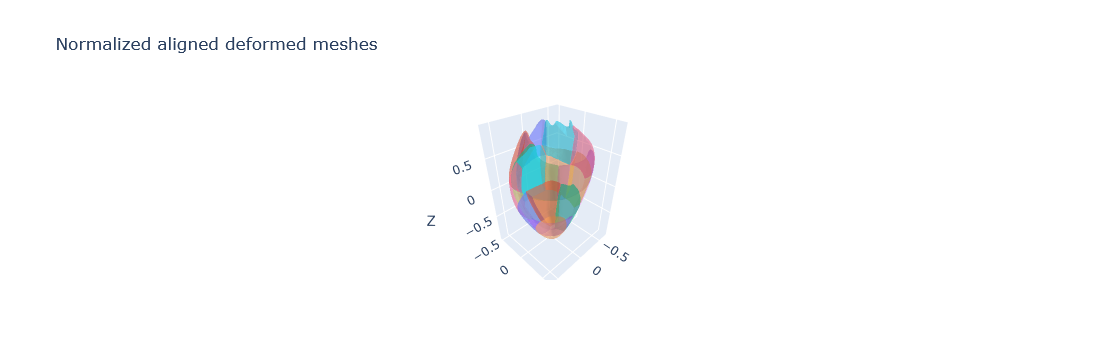

In [ ]:
# ==========================================================
# 6. Plot
# ==========================================================

fig = go.Figure()


for name, mesh in mesh_dict_deformed_saved.items():

    verts = mesh.verts_packed().cpu().numpy()
    faces = mesh.faces_packed().cpu().numpy()


    fig.add_trace(go.Mesh3d(
        x=verts[:,0],
        y=verts[:,1],
        z=verts[:,2],
        i=faces[:,0],
        j=faces[:,1],
        k=faces[:,2],
        opacity=0.35,
        name=name
    ))


fig.update_layout(
    title="Normalized aligned deformed meshes",
    scene=dict(
        aspectmode="data",
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z"
    ),
)


fig.show()